# ML02 - Machine Learning Fall 2024

- **Name:** `Mohammad Ali Olama`
- **Student ID:** `####`

---

### Submission Deadline: **November 6, 2024**
#### Submit your assignment via Microsoft Teams.
#### File Naming Format: `ML02_LASTNAME_STUDENTID.ipynb`

---

### *Instructions for Completing the Problem Set:*

- The problem set includes both coding and written response questions. For coding tasks, complete all code blocks marked with `YOUR CODE HERE`.
  
- For written answers, replace the placeholder text `[Your answer here]`  with your response.

- You are allowed to use AI assistance for this assignment, but you must fully disclose any AI usage in the final cell of this notebook. Please include any prompts you used with AI tools. Failure to disclose AI assistance will result in a zero on the assignment, as we have tools in place to detect such cases. We encourage transparency—there are no restrictions on AI use, so there's no reason not to be honest!

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<hr>

### **<font face="Courier New" color="blue" size="+3">Question 1: Binary Classification (30 points)</font>**





In this question, you will explore the **K-Nearest Neighbors (KNN)** classifier for binary classification using the **moons dataset**. The task will guide you through the essential steps of working with machine learning models, including data generation, model training, hyperparameter tuning, model evaluation, and comparing performance metrics. Additionally, you will explore advanced techniques such as cross-validation, ROC-AUC curves, and decision threshold optimization. By the end of this exercise, you will gain a better understanding of how to effectively apply the KNN algorithm and analyze its performance using various evaluation metrics.

---



---



---



---



---


---



---


---





####<font face="Verdana" color="green" size="+2"> **Part 1: Data Generation and Visualization** (3 points)


The moons dataset is a synthetic dataset that consists of two interleaving half circles, useful for binary classification tasks. Here, we generate the dataset using the `make_moons()` function from `sklearn`, with 10,000 samples and Gaussian noise to introduce some complexity. This helps create a challenging classification task that cannot be solved easily by linear models.


In this part, you need to visualize the generated dataset, clearly showing the two classes and understanding the distribution of the points.



*   Generate moons dataset
*   Plot the dataset



In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import necessary libraries
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

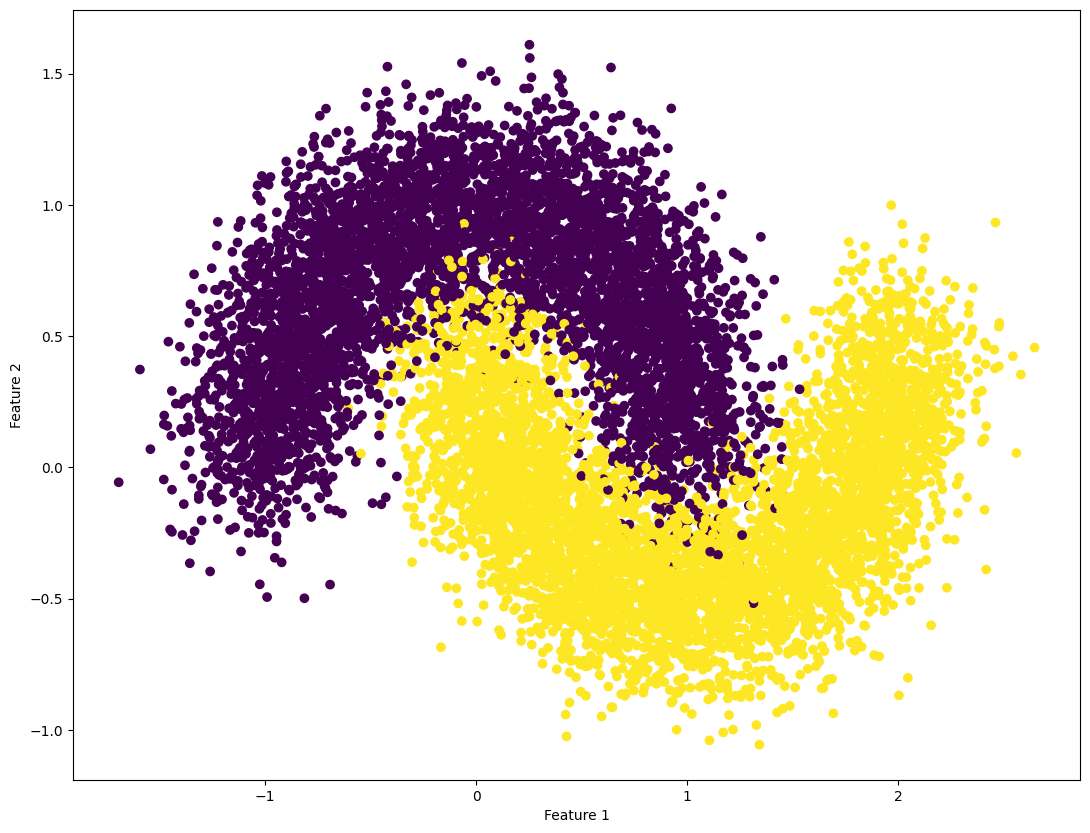

In [4]:
X, y = make_moons(n_samples=10000, noise=0.2, random_state=42)

plt.figure(figsize=(13,10))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

####<font face="Verdana" color="green" size="+2"> **Part 2: Train-Test Split** (2 points)

In this part, you should split the dataset into a **training set** and a **test set**. You will use an 80-20 split, where 80% of the data will be used for training and 20% for testing.



In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

####<font face="Verdana" color="green" size="+2"> **Part 3: Hyperparameter Tuning with Grid Search** (7 points)

KNN relies heavily on hyperparameters such as the number of neighbors (`n_neighbors`) and the distance weighting method (`weights`). **Grid search with cross-validation** helps identify the best combination of hyperparameters by systematically evaluating multiple models with different parameter values. In this part, you will try various values for `n_neighbors` and `weights`, using cross-validation to select the best model based on desired metrics.

  
You will explain how grid search works and why cross-validation is critical in selecting robust hyperparameters. Then, you will report the best hyperparameters found during grid search and justify their selection.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [2 , 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='f1', verbose = 5)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END ....n_neighbors=2, weights=uniform;, score=0.943 total time=   0.3s
[CV 2/5] END ....n_neighbors=2, weights=uniform;, score=0.958 total time=   0.2s
[CV 3/5] END ....n_neighbors=2, weights=uniform;, score=0.965 total time=   0.2s
[CV 4/5] END ....n_neighbors=2, weights=uniform;, score=0.957 total time=   0.2s
[CV 5/5] END ....n_neighbors=2, weights=uniform;, score=0.952 total time=   0.1s
[CV 1/5] END ...n_neighbors=2, weights=distance;, score=0.943 total time=   0.0s
[CV 2/5] END ...n_neighbors=2, weights=distance;, score=0.961 total time=   0.0s
[CV 3/5] END ...n_neighbors=2, weights=distance;, score=0.964 total time=   0.0s
[CV 4/5] END ...n_neighbors=2, weights=distance;, score=0.965 total time=   0.0s
[CV 5/5] END ...n_neighbors=2, weights=distance;, score=0.959 total time=   0.0s
[CV 1/5] END ....n_neighbors=3, weights=uniform;, score=0.958 total time=   0.2s
[CV 2/5] END ....n_neighbors=3, weights=uniform;

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [2, 3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='f1', verbose=5)

Grid Search creates a grid for different possible values for some hyperparameters of the model, and then it will train and evaluate each model using every single unique combination of these hyperparameters. Since we are not allowed to evaluate each model (we think of each model with different hyperparameters as different models) on the Test set, we need to somehow mimic the test data, meaning that we need an unseen dataset which is not used in the process of training each model. So cross-validation technique is used, were the training set is split into $k$ sets.

At each step, the model chooses one of the folds as validation set, and the rest folds as training set.
Then we fit our model on the training set, and evaluate their performance on the validation set.
 It will do this for $k$ steps, resulting in $k$ different score (e.g. accuracy, or F1-score). The average of these $k$ scores will be saved and reported as the final score for that combination of hyperparameters.

 Finally, a model who outperforms other models on the final average score selected as the final model. (It's essential to note that we cannot use training metrics (e.g. training accuracy or training loss) as a measurement to compare different models during training phase, since it can lead to overfitting and poor performance on test set.)

Best hyperparameters are:

In [7]:
print("Best hyperparameters:", grid_search.best_params_)

print("Best cross-validation score:", grid_search.best_score_)

Best hyperparameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best cross-validation score: 0.9702370491252255


* Larger n_neighbors values generally lead to smoother decision boundaries(since we have more smaller neighborhoods), which is beneficial for the non-linearly separable make_moons dataset.

* weights='uniform' ensures equal influence from all neighbors, potentially reducing the effect of noise.(The other choice is 'distance', which give each neighbor in the neighborhood a weight based on its distance from the sample.)


Now, let's consider another grid:

In [8]:
param_grid2 = {
    'n_neighbors': [2 , 3, 5, 7, 9, 11 , 13 , 15 , 17 , 19],
    'weights': ['uniform', 'distance']
}

knn2 = KNeighborsClassifier()

grid_search2 = GridSearchCV(estimator=knn2, param_grid=param_grid2, cv=5, scoring='f1')

grid_search2.fit(X_train, y_train)

print("Best hyperparameters:", grid_search2.best_params_)

print("Best cross-validation score:", grid_search.best_score_)

Best hyperparameters: {'n_neighbors': 19, 'weights': 'distance'}
Best cross-validation score: 0.9702370491252255


we were right about the n_neighbors. the models tries to choose a combination with more n_neighbors, since it will creates smoother neighborhood boundaries, leading to more accurate predictions.

but how about 'weights': 'distance' ? I think that now our model is also considering data density in each neighborhood. Giving more weight to closer neighbors likely improves the model's ability to capture the local structure of the data. (I'M not sure, jsut gussing =] )

####<font face="Verdana" color="green" size="+2">**Part 4: Model Training and Evaluation** (5 points)

Once the optimal hyperparameters are found, the next step is to train the KNN classifier on the entire training dataset and evaluate its performance on the test set. Two primary metrics will be used: **accuracy** and the **confusion matrix**. Accuracy gives an overall measure of performance, while the confusion matrix provides deeper insight into the types of errors the model makes (false positives and false negatives).

You should explain how the confusion matrix can be used to assess different types of classification errors and provide insights into where the model performs well and where it struggles.

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred , digits = 6)

print(report)

              precision    recall  f1-score   support

           0   0.982880  0.963475  0.973081      1013
           1   0.963257  0.982776  0.972919       987

    accuracy                       0.973000      2000
   macro avg   0.973069  0.973125  0.973000      2000
weighted avg   0.973196  0.973000  0.973001      2000



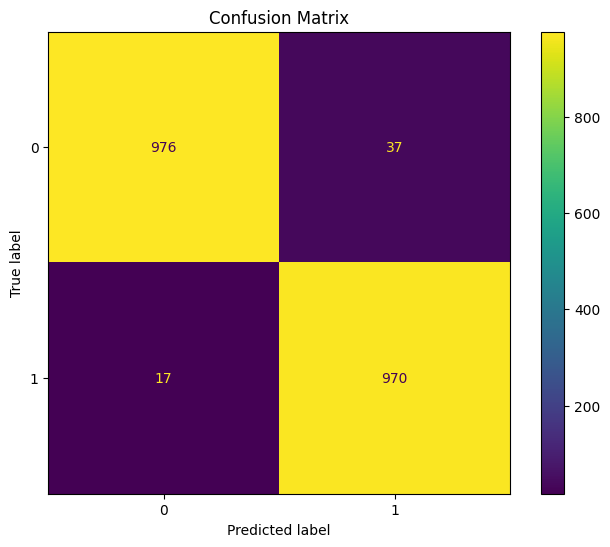

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8,6))

display = ConfusionMatrixDisplay(cm, display_labels=best_knn.classes_)

ax.set(title='Confusion Matrix')

display.plot(ax=ax);

A confusion matrix is a table that visualizes the performance of a classification model.
The confusion matrix reveals the types and frequencies of errors made by a classifier:

* False Positives Errors (FP): Indicate instances where the model incorrectly predicted the positive class. These errors can be costly in certain scenarios (e.g., diagnosing a healthy person with a disease).

* False Negatives Errors(FN): Indicate instances where the model incorrectly predicted the negative class. These errors can also have significant consequences (e.g., failing to detect a disease in a sick person).

We can calculate the overall accuracy by summing the correctly classified instances (TP + TN) and dividing by the total number of instances. However, accuracy alone might not be sufficient, especially for imbalanced datasets.
We can also calculate other metrics like precision, recall, and F1-score. This is crucial for multi-class classification problems and imbalanced datasets.


####<font face="Verdana" color="green" size="+2">**Part 5: K-Fold Cross-Validation with ROC-AUC Curve** (6 points)


Cross-validation, especially **k-fold cross-validation**, ensures that the model’s performance is evaluated more rigorously by training and testing it multiple times on different subsets of the data. In this part, you will use cross-validation to evaluate the **ROC-AUC** (Receiver Operating Characteristic - Area Under Curve), a more nuanced metric than accuracy. The AUC score measures how well the model distinguishes between the two classes, with values closer to 1 indicating better performance.

  
You should explain how k-fold cross-validation helps in assessing model performance reliably, and discuss how the ROC curve illustrates the trade-off between the true positive rate and false positive rate. You will also interpret the AUC score and its implications for model performance.

Average ROC-AUC score: 0.9919630396671859


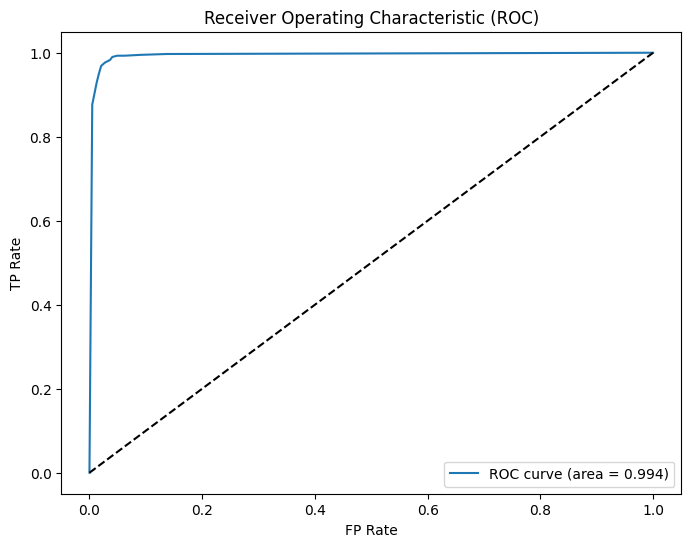

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve


cv_scores = cross_val_score(best_knn, X_train, y_train, cv=5, scoring='roc_auc')
print("Average ROC-AUC score:", cv_scores.mean())


# The predict_proba function will generate probability that sample belongs to each class.
# Predict probabilities for the positive class on the test set.
# these probabilities will be used in roc_curve and roc_auc_score functions.
y_pred_proba = best_knn.predict_proba(X_test)[:, 1]

# Calculate the ROC curve.
# According to roc_curve documentation, we should pass :
# y_true:
#     True binary labels. If labels are not either {-1, 1} or {0, 1}, then pos_label should be explicitly given.
# y_score:
#     Target scores, can either be probability estimates of the positive class, confidence values, or non-thresholded measure of decisions (as returned by “decision_function” on some classifiers).
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.3f})'.format( roc_auc))
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier line
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.show()


**K-fold cross-validation** helps in assessing model performance reliably by reducing overfitting. By training and testing the model on multiple subsets of the data, cross-validation helps to reduce the risk of overfitting, where the model performs well on the training data but poorly on unseen data.Also, it provides a more robust estimate of performance and estimate of how well the model will generalize to new data by averaging the performance across multiple folds.

**The ROC curve** illustrates the trade-off between the true positive rate and the false
 positive rate at different treshholds. The area under this curve is called AUC. notice the tha maximum area for this curve is 1: both axes ranges from 0 to 1.

The AUC score is a measure of the overall performance of the model
 across all possible classification thresholds. A higher AUC score indicates that the model is better
 at distinguishing between the positive and negative classes.
 In our case, an AUC score of around 0.99 suggests that the model is performing well at
 distinguishing between the two classes in the moons dataset.

####<font face="Verdana" color="green" size="+2">**Part 6: Precision-Recall Trade-off and Threshold Adjustment** (4 points)

While the default decision threshold for KNN is 0.5 (for binary classification), in some cases, adjusting the threshold can improve performance based on specific needs (e.g., maximizing precision or recall). In this part, you will explore how changing the threshold affects **precision** and **recall**, two critical metrics in classification, particularly for imbalanced datasets. The **F1-score**, a combination of precision and recall, will help you determine the best threshold.

  
You should explain how precision and recall vary with different thresholds, and why in some cases it may be preferable to adjust the threshold to meet specific performance goals (such as reducing false positives or false negatives). You will also justify the selected threshold based on the F1-score.

***Answer:***

First let's see how knn is working: when it sees new data point, it will assign $2$ probability values $p_0 , p_1$(assuming we have $2$ classes) to this datapoint. With default treshhold, the datapoint will be classified as class $0$ if $p_0 \geq 0.5$ and classified as $1$ vice versa.

So we can change this $0.5$ treshhold and get completely different results. new datapoints will be classified as different classes, which ultimately leads to different values for TP,TN,FP,FN $⇒$ different values for precision and recall.

we may want to change this treshhold when we have imbalanced dataset (probability of occuring a class is significantly different from other class.). Moreover, nn some applications, the cost of a false positive is different from the cost of a false negative. For example, in medical diagnosis, a false negative (missing a disease) could be much more dangerous than a false positive (incorrectly diagnosing a healthy person).

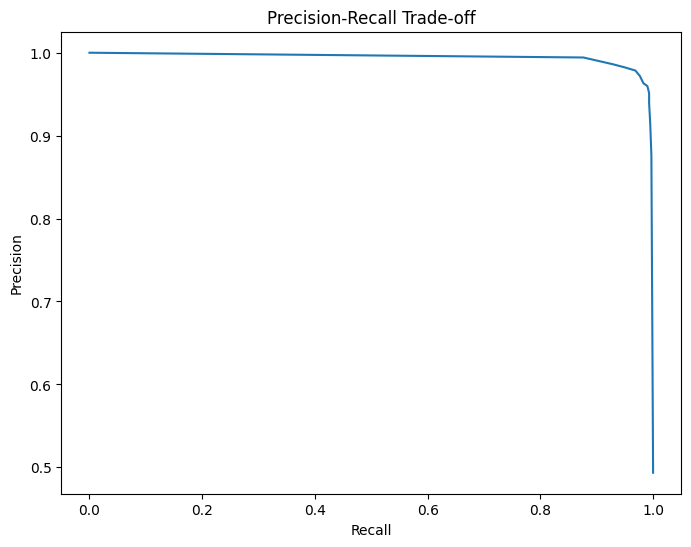

In [12]:
from sklearn.metrics import precision_recall_curve, f1_score

# The predict_proba function will generate probability that sample belongs to each class.
# Predict probabilities for the positive class on the test set.
# these probabilities will be used in roc_curve and roc_auc_score functions.
y_pred_proba = best_knn.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot the precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off')
plt.show()

Now let's focus on F1 and find the best treshold:

In [13]:
# Find the threshold that maximizes the F1-score
f1_scores =[]

for threshold in thresholds:
  f1_scores.append(f1_score(y_test, y_pred_proba >= threshold))

max_f1 = max(f1_scores)
optimal_index = f1_scores.index(max_f1)
optimal_threshold = thresholds[optimal_index]

print('Max F1-score: {} which occurs at threshold {}'.format(max_f1, optimal_threshold))

Max F1-score: 0.9745635910224439 which occurs at threshold 0.45454545454545453


####<font face="Verdana" color="green" size="+2"> **Part 7: Model Comparison** (3 points)
  
After adjusting the threshold, it is important to compare the performance of the original KNN model (with the default threshold) and the threshold-adjusted model. You will evaluate the test performance of both models and determine if adjusting the threshold improves the performance based on metrics such as accuracy and F1-score.


You should compare the results of both models and explain how threshold adjustment can impact the model’s performance, providing insights into situations where it may be beneficial to optimize the threshold.


Now you can use this optimal threshold for prediction.(Notice that the treshhold is near 0.5, so it might not have very much effect on the result!

In [14]:
y_pred_adjusted = (y_pred_proba >= optimal_threshold).astype(int)

cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
report_adjusted = classification_report(y_test, y_pred_adjusted , digits=6)

print("original report: ")
print(report)

print("adjusted report: ")
print(report_adjusted)


original report: 
              precision    recall  f1-score   support

           0   0.982880  0.963475  0.973081      1013
           1   0.963257  0.982776  0.972919       987

    accuracy                       0.973000      2000
   macro avg   0.973069  0.973125  0.973000      2000
weighted avg   0.973196  0.973000  0.973001      2000

adjusted report: 
              precision    recall  f1-score   support

           0   0.989817  0.959526  0.974436      1013
           1   0.959725  0.989868  0.974564       987

    accuracy                       0.974500      2000
   macro avg   0.974771  0.974697  0.974500      2000
weighted avg   0.974966  0.974500  0.974499      2000



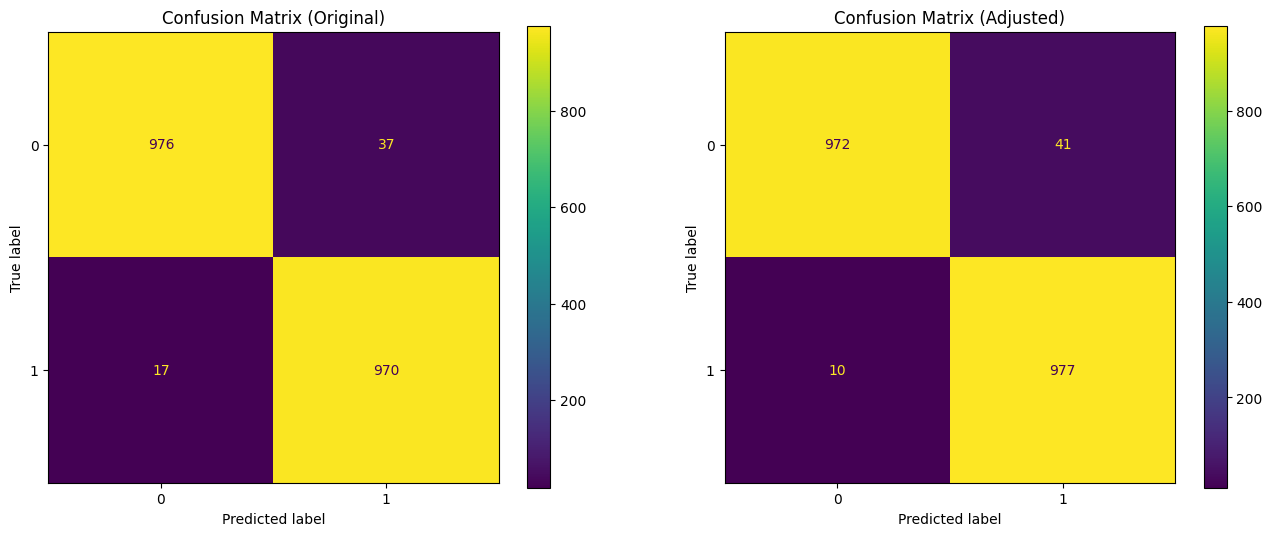

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot cm on the left subplot
display_cm = ConfusionMatrixDisplay(cm, display_labels=best_knn.classes_)
display_cm.plot(ax=ax1)
ax1.set_title('Confusion Matrix (Original)')

# Plot cm_adjusted on the right subplot
display_cm_adjusted = ConfusionMatrixDisplay(cm_adjusted, display_labels=best_knn.classes_)
display_cm_adjusted.plot(ax=ax2)
ax2.set_title('Confusion Matrix (Adjusted)')

plt.show()

It seems that changing this treshhold has some effects. the following differences are evident:

1. Accuracy ,precision, recall, and F1-score are all improved.
2. Number of TP is increased, but number of TN samples decreased.
3. number of FN are deacred (from 17 to 10), on the other hand number of FP increased (from 37 to 41)

Ultimately, by adjustig treshhold, our models f1-score has improved!

### **<font face="Courier New" color="blue" size="+3">Question 2: Multi-class Classification (30 points) </font>**



In this question, you will be working on a **multi-class classification** problem using a dataset that provides comprehensive mobile device usage patterns. The goal is to classify users into one of five behavior classes based on various metrics such as app usage time, screen-on time, battery drain, and data consumption. This dataset is valuable for studying user behavior patterns, which can be applied to domains like user experience optimization, battery management, and app recommendations.

The dataset contains 700 samples, each representing a user's interaction with their mobile device. The key features of the dataset include:

- **User ID**: A unique identifier for each user.
- **Device Model**: The model of the user's smartphone (categorical feature).
- **Operating System**: The operating system of the device (iOS or Android).
- **App Usage Time**: The daily time spent on mobile applications, measured in minutes.
- **Screen On Time**: The average number of hours per day the screen is active.
- **Battery Drain**: Daily battery consumption in mAh (milliampere-hours).
- **Number of Apps Installed**: The total number of apps installed on the device.
- **Data Usage**: The amount of daily mobile data consumption, measured in megabytes (MB).
- **Age**: The age of the user (numerical feature).
- **Gender**: The gender of the user (categorical feature - Male or Female).
- **User Behavior Class**: The target variable, which categorizes user behavior based on their mobile usage patterns into five classes (ranging from 1 to 5, where 1 represents light usage and 5 represents extreme usage).


This dataset presents an opportunity to practice data cleaning, exploratory data analysis (EDA), and classification using multiple machine learning algorithms. You will evaluate the performance of different classifiers using key metrics such as accuracy, precision, recall, F1-score, and confusion matrix, while also exploring feature importance to gain insight into the most influential factors affecting the classification.



**You should use `user_behavior_dataset.csv` file for this question**



#### **Scope of the Question**

In this question, you will work with a real-world multi-class classification problem using a dataset of **mobile device usage patterns**. The task is to classify users into one of five **user behavior classes** based on their usage patterns. This dataset presents an opportunity to practice data cleaning, exploratory data analysis (EDA), and classification using multiple machine learning algorithms. You will evaluate the performance of different classifiers using key metrics such as accuracy, precision, recall, F1-score, and confusion matrix, while also exploring feature importance to gain insight into the most influential factors affecting the classification.

---



---



---



---



---


---



####<font face="Verdana" color="green" size="+2"> **Part 1: Data Cleaning** (5 points)

Before applying any machine learning model, it is essential to clean the dataset to ensure quality results. In this part, you will handle missing values, remove duplicates (if any), and deal with incorrect data types (e.g., converting categorical columns into numerical representations). You will also verify that there are no outliers or errors in the dataset.

Perform the necessary cleaning steps to prepare the data for further analysis and classification. Describe any issues you encounter and how you resolve them (e.g., filling missing values, encoding categorical features).

**Key Steps**:
- Check for and handle missing values.
- Convert categorical columns (e.g., Gender, Operating System) into numerical representations.
- Remove duplicates if they exist.
- Handle any data inconsistencies.

In [16]:
import pandas as pd
import seaborn as sns

data_org = pd.read_csv('/content/drive/MyDrive/TEIAS/ML/HW2/user_behavior_dataset.csv')

data_org.head()


,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [17]:
data_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


## Duplicates

First let's deal with duplicate values:

In [18]:
data = data_org.drop_duplicates()

In [19]:
print('number of duplicate rows: {}'.format(len(data_org) - len(data)))

number of duplicate rows: 0


## Missing values

No missing values!
(خدایا شکرت!)

In [20]:
missing_values = data.isnull().sum()

missing_values

,0
User ID,0
Device Model,0
Operating System,0
App Usage Time (min/day),0
Screen On Time (hours/day),0
Battery Drain (mAh/day),0
Number of Apps Installed,0
Data Usage (MB/day),0
Age,0
Gender,0


## Categorical variables

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


Only 'Device Model' , 'Operating System' and 'Gender' are variables that are categorical but not in integer format! so let's convert them:

In [22]:
categorical_features = ['Device Model', 'Operating System', 'Gender']

data = pd.get_dummies(data, columns=categorical_features , dtype=int)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   User ID                          700 non-null    int64  
 1   App Usage Time (min/day)         700 non-null    int64  
 2   Screen On Time (hours/day)       700 non-null    float64
 3   Battery Drain (mAh/day)          700 non-null    int64  
 4   Number of Apps Installed         700 non-null    int64  
 5   Data Usage (MB/day)              700 non-null    int64  
 6   Age                              700 non-null    int64  
 7   User Behavior Class              700 non-null    int64  
 8   Device Model_Google Pixel 5      700 non-null    int64  
 9   Device Model_OnePlus 9           700 non-null    int64  
 10  Device Model_Samsung Galaxy S21  700 non-null    int64  
 11  Device Model_Xiaomi Mi 11        700 non-null    int64  
 12  Device Model_iPhone 12

In [23]:
data.head()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class,Device Model_Google Pixel 5,Device Model_OnePlus 9,Device Model_Samsung Galaxy S21,Device Model_Xiaomi Mi 11,Device Model_iPhone 12,Operating System_Android,Operating System_iOS,Gender_Female,Gender_Male
0,1,393,6.4,1872,67,1122,40,4,1,0,0,0,0,1,0,0,1
1,2,268,4.7,1331,42,944,47,3,0,1,0,0,0,1,0,1,0
2,3,154,4.0,761,32,322,42,2,0,0,0,1,0,1,0,0,1
3,4,239,4.8,1676,56,871,20,3,1,0,0,0,0,1,0,0,1
4,5,187,4.3,1367,58,988,31,3,0,0,0,0,1,0,1,1,0


## Inconsistancies ?
Let's draw pairplots:

In [24]:
sns.pairplot(data_org, hue='User Behavior Class');

Output hidden; open in https://colab.research.google.com to view.

Everything looks normal! no outlier seems to exist in the dataset.

####<font face="Verdana" color="green" size="+2"> **Part 2: Exploratory Data Analysis (EDA)** (7 points)

  
EDA helps to understand the structure and relationships within the data. In this part, you will visualize the distribution of the features and explore their relationships with the target variable (`User Behavior Class`). You will create appropriate visualizations (e.g., histograms, bar plots, box plots) and calculate summary statistics to identify key trends and patterns.

For each part, explain about the insight that plot gives you about the dataset.



#####<font face="Verdana" color="blue" size="+1"> **Part 2.1: Age vs. Average App Usage Time Line Plot**

This plot will show how app usage time varies with age.

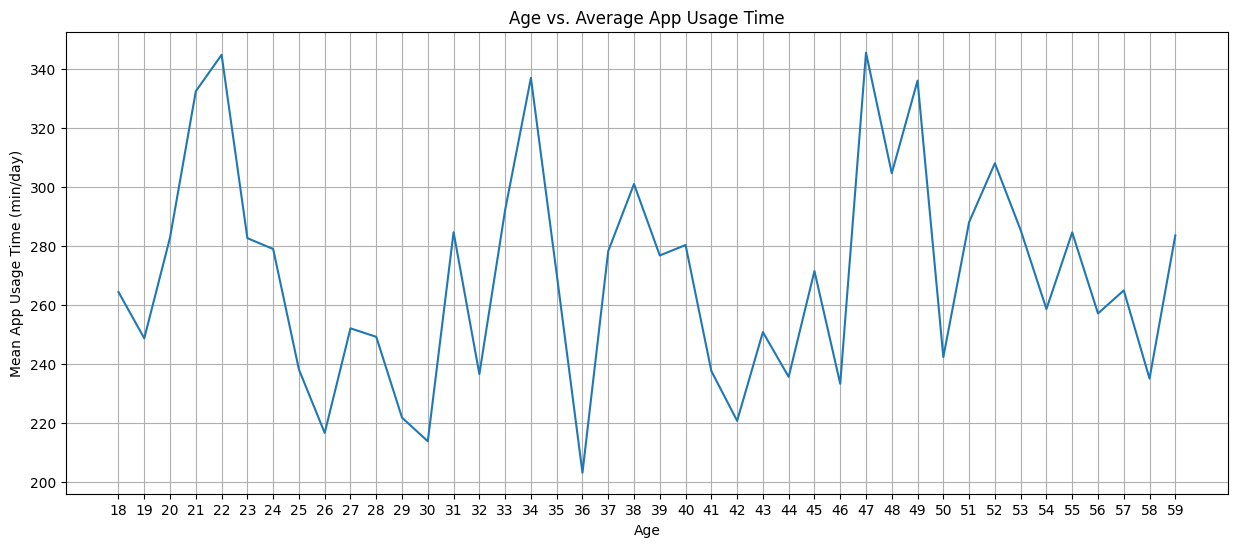

In [25]:
# Group data by age and calculate the mean of 'App Usage Time (min/day)'
age_app_usage_mean = data.groupby('Age')['App Usage Time (min/day)'].mean().reset_index()

# Create a line plot
plt.figure(figsize=(15, 6))
plt.plot(age_app_usage_mean['Age'], age_app_usage_mean['App Usage Time (min/day)'])
plt.xlabel('Age')
plt.ylabel('Mean App Usage Time (min/day)')
plt.title('Age vs. Average App Usage Time')
plt.xticks(range(min(data['Age']), max(data['Age']) + 1))
plt.grid(True)
plt.show()

The result is very chaotic! There is no obvious pattern in app usage time.

#####<font face="Verdana" color="blue" size="+1"> **Part 2.2: Countplot of Users per Device Model**

Visualize how many users are using each device model.


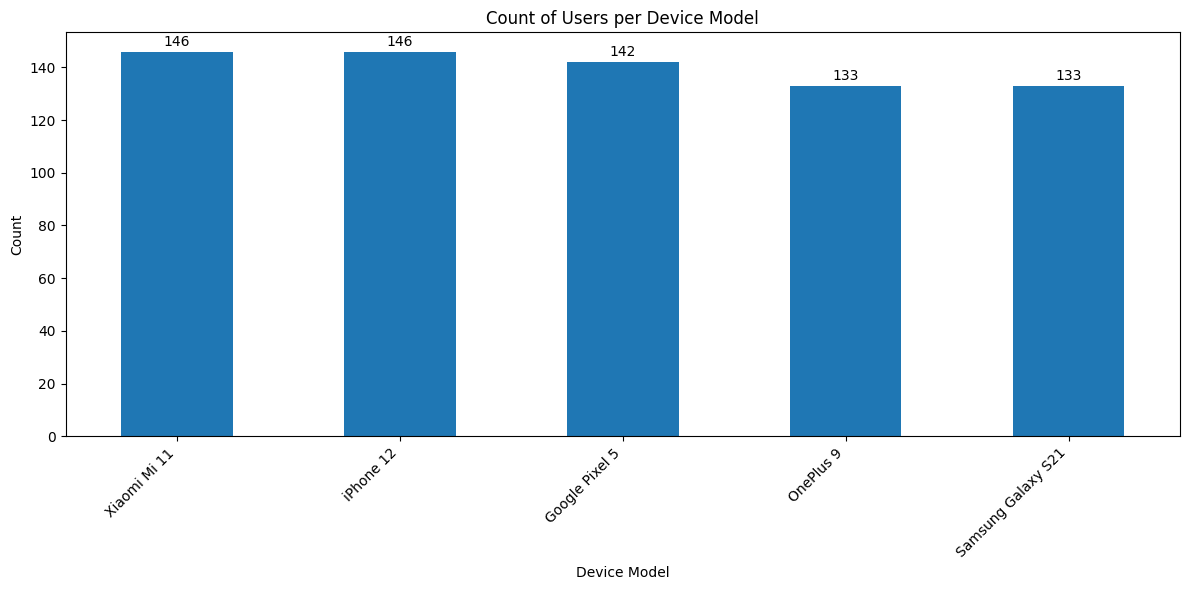

In [26]:
plt.figure(figsize=(12, 6))
data_org['Device Model'].value_counts().plot(kind='bar')
plt.xlabel('Device Model')
plt.ylabel('Count')
plt.title('Count of Users per Device Model')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with its count
for i, v in enumerate(data_org['Device Model'].value_counts()):
  plt.text(i, v + 1, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

It seems that we have an almost balanced dataset in terms of device model! (However notice that in terms of operating system, the dataset is inbalanced, since only iPhone 12 is using IOS, and other devices are android phones.)

##### <font face="Verdana" color="blue" size="+1"> **Part 2.3: App Usage Time vs. Screen On Time for Different Behavior Classes**

Explore the relationship between app usage and screen on time across different user behavior classes.

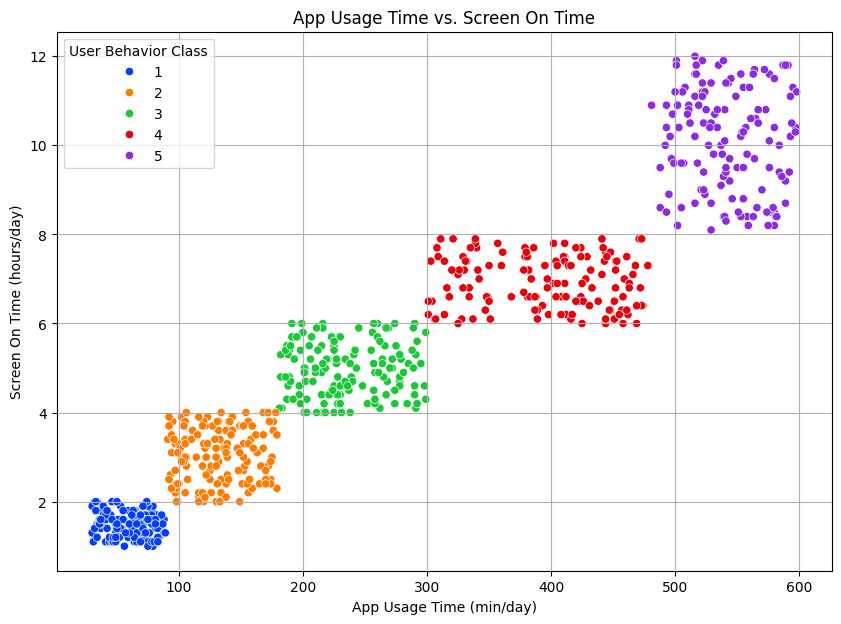

In [27]:
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=data,
    x='App Usage Time (min/day)',
    y='Screen On Time (hours/day)',
    hue='User Behavior Class',
    palette='bright',
    alpha=1
)
plt.title('App Usage Time vs. Screen On Time')
plt.xlabel('App Usage Time (min/day)')
plt.ylabel('Screen On Time (hours/day)')
plt.legend(title='User Behavior Class')
plt.grid()
plt.show()

It looks like we have a high correlation between app usage time and screen on time. Also the correlation between both these variables with target variable (User Behavior Class) is evident. We will calculate correlations in the future parts.

##### <font face="Verdana" color="blue" size="+1"> **Part 2.4: Box Plot of App Usage Time by Operating System**

Compare the app usage time between iOS and Android users.

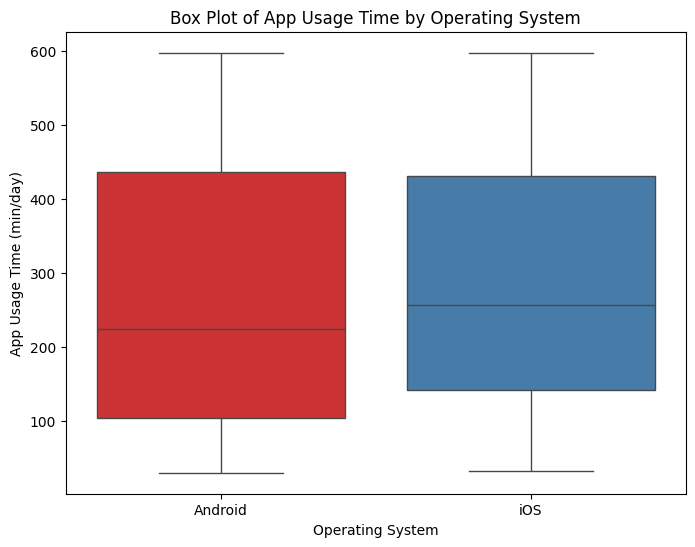

In [28]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Operating System', y='App Usage Time (min/day)', data=data_org , palette='Set1')
plt.xlabel('Operating System')
plt.ylabel('App Usage Time (min/day)')
plt.title('Box Plot of App Usage Time by Operating System')
plt.show()


In [29]:
data_org.groupby('Operating System')['App Usage Time (min/day)'].describe()

,count,mean,std,min,25%,50%,75%,max
Operating System,,,,,,,,
Android,554.0,268.258123,179.188678,30.0,104.25,225.0,436.75,598.0
iOS,146.0,282.020548,169.592390,32.0,142.25,257.5,431.75,597.0


Minimum and maximum app usage amont ios and android users are approximately equal. However, ios users, on average, have used their device (in terms of App Usage Time) more than android users.

##### <font face="Verdana" color="blue" size="+1"> **Part 2.5: Bar Plot of User Behavior Class by Gender**

 Visualize the distribution of user behavior classes across genders.

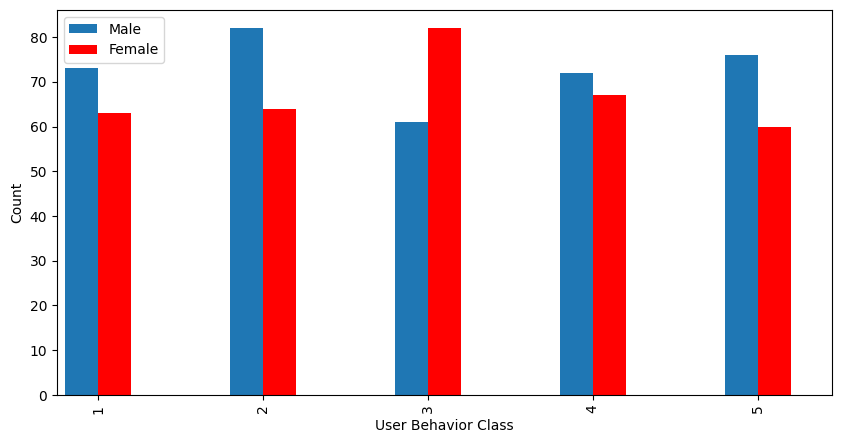

In [30]:
data_D = data_org.groupby(['User Behavior Class', 'Gender'])['User Behavior Class'].value_counts().reset_index()
data_D

ax = data_D[data_D.Gender == 'Male'].plot.bar(x='User Behavior Class',y='count',position=1,width=.2,figsize=(10,5))
data_D[data_D.Gender == 'Female'].plot.bar(x='User Behavior Class',y='count',ax=ax,color='red',position=0,width=.2)

# Now let's setup the labels, titles and format y axis as percentages
plt.legend(['Male','Female'])
plt.ylabel('Count')
plt.xlabel('User Behavior Class')
plt.show()

##### <font face="Verdana" color="blue" size="+1"> **Part 2.6: Joint Plot of App Usage Time and Battery Drain**

 Analyze the relationship between app usage time and battery drain.

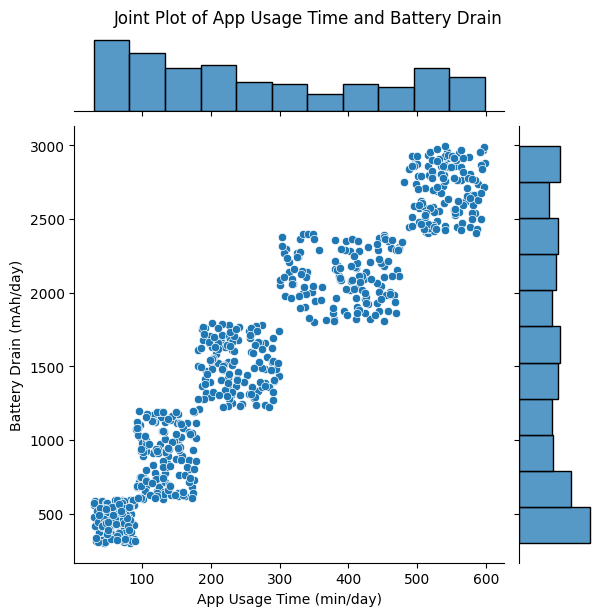

In [31]:
sns.jointplot(x='App Usage Time (min/day)', y='Battery Drain (mAh/day)', data=data)
plt.suptitle('Joint Plot of App Usage Time and Battery Drain', y=1.02)
plt.show()

##### <font face="Verdana" color="blue" size="+1"> **Part 2.7: Correlation Heatmap of Numerical Features**

 Examine the correlations between the numerical features to understand how they are related to each other.

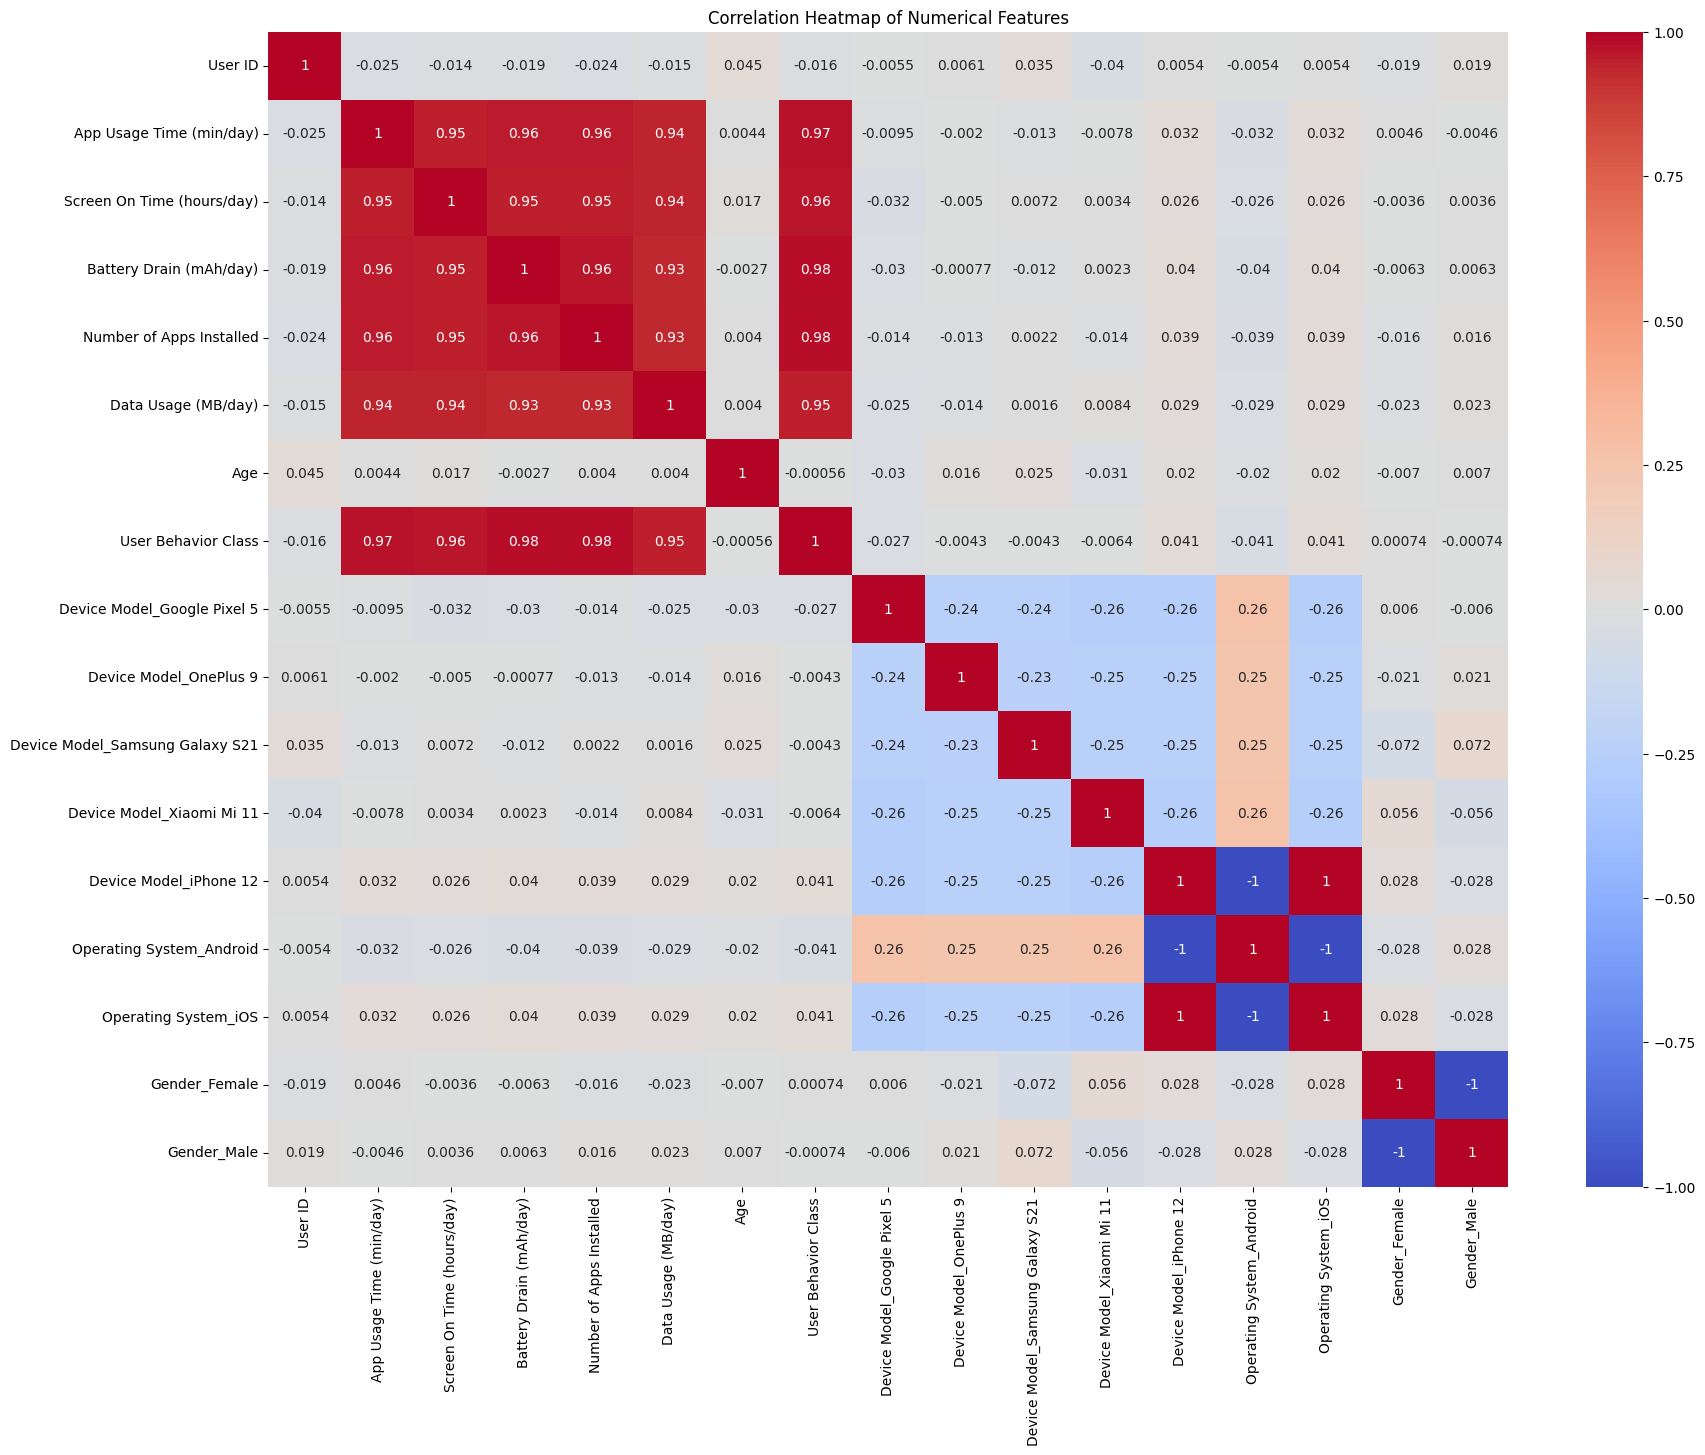

In [32]:
# all variables are converted to numerical in previous steps:

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Plot the correlation heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

As we discussed earlier, 'App Usage Time' and 'Screen On Time' has high correlation.(It's normal!) also it's evident from the cahrt that the target variable(User class) has very high correlation with these variables :

1.  App Usage Time
2. Screen On Time
3. Battery Drain
4. Number of Apps Installed
5. Data Usage

other variables have almost no effect on the target variable, So I think we can remove them in the future steps (feature selection)

#### <font face="Verdana" color="green" size="+2">**Part 3: Model Selection and Training** (9 points)

In this section, you will apply different machine learning classifiers to the dataset. Possible models to try include:
- **Logistic Regression** (for baseline comparison)
- **Decision Tree Classifier**
- **Random Forest Classifier**
- **K-Nearest Neighbors (KNN)**
- **Support Vector Classifier (SVC)**

Each model has its strengths and weaknesses in multi-class classification tasks. You will train each model and compare their performance using cross-validation to ensure a fair comparison. Explain why certain models perform better or worse for this task.

At the end, summarize the findings and provide a final recommendation on the best model for this dataset.

**Attention**: In this process, you may need to scale features to achieve better results!

In [33]:
from sklearn.preprocessing import StandardScaler

X = data.drop('User Behavior Class', axis=1)
y = data['User Behavior Class']

# Split the data into training and testing sets
X_train_org, X_test_org, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# using StandardScaler. fit_transform on train data and transform the result to test data.
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_org), columns = X.columns)
X_test = pd.DataFrame(scaler.transform(X_test_org) , columns = X.columns)

## Logistic Regression

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        23

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



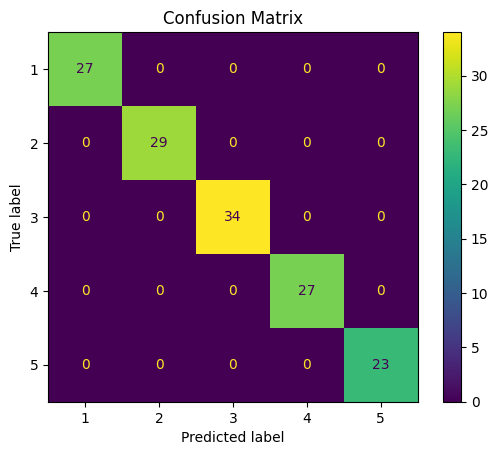

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# since we have multi-class, we should use 'multinomial'
logistic = LogisticRegression(multi_class='multinomial')
logistic.fit(X_train, y_train)

# make predictions
y_pred = logistic.predict(X_test)

# metrics
logistic_report = classification_report(y_test, y_pred)
logistic_cm = confusion_matrix(y_test, y_pred)

# results
print("Classification Report:\n", logistic_report)

fig, ax = plt.subplots()
logistic_display = ConfusionMatrixDisplay(logistic_cm, display_labels=logistic.classes_)
ax.set(title='Confusion Matrix')
logistic_display.plot(ax=ax);

Complete OVERFIT! (The dataset is small! and we had 5 variables with very high correlation with the target variable!)

## Decision Tree

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        23

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



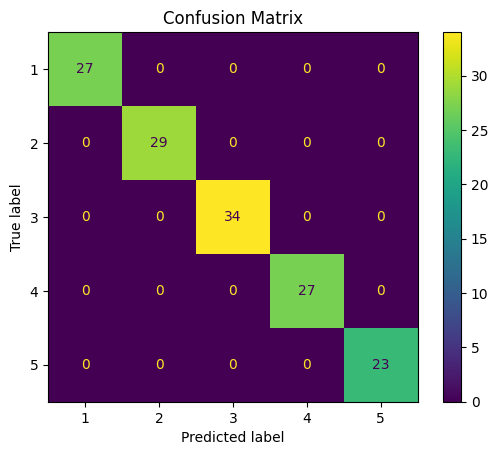

In [35]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

# predict
y_pred = tree.predict(X_test)

# Evaluate the model
tree_report = classification_report(y_test, y_pred)
tree_cm = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", tree_report)

fig, ax = plt.subplots()
tree_display = ConfusionMatrixDisplay(tree_cm, display_labels=tree.classes_)
ax.set(title='Confusion Matrix')
tree_display.plot(ax=ax);

Same as Logistic Regression

## Random forest

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        23

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



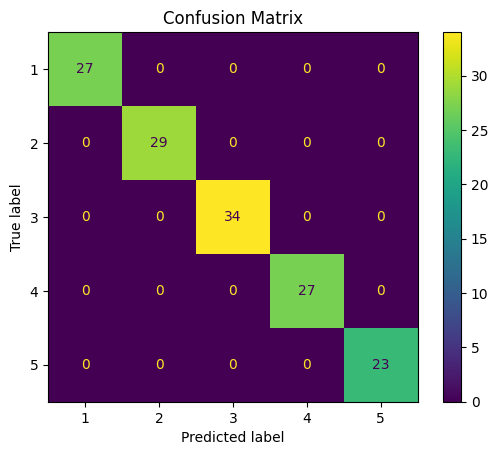

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# predict
y_pred = rf.predict(X_test)

# Evaluate the model
rf_report = classification_report(y_test, y_pred)
rf_cm = confusion_matrix(y_test, y_pred)


print("Classification Report:\n", rf_report)

fig, ax = plt.subplots()
rf_display = ConfusionMatrixDisplay(rf_cm, display_labels=rf.classes_)
ax.set(title='Confusion Matrix')
rf_display.plot(ax=ax);

Same as previous

## SVC

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        23

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



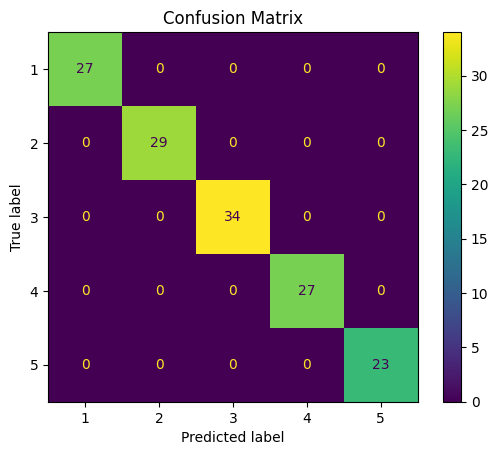

In [37]:
from sklearn.svm import SVC

svc = SVC(probability=True)
svc.fit(X_train, y_train)

# predict
y_pred = svc.predict(X_test)

# Evaluate the model
svc_report = classification_report(y_test, y_pred)
svc_cm = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", svc_report)

fig, ax = plt.subplots()
svc_display = ConfusionMatrixDisplay(svc_cm, display_labels=svc.classes_)
ax.set(title='Confusion Matrix')
svc_display.plot(ax=ax);

Same as previous

## K-Nearest Neighbors (KNN)


Classification Report:
               precision    recall  f1-score   support

           1       0.86      0.89      0.87        27
           2       0.71      0.83      0.76        29
           3       0.84      0.79      0.82        34
           4       1.00      0.85      0.92        27
           5       1.00      1.00      1.00        23

    accuracy                           0.86       140
   macro avg       0.88      0.87      0.87       140
weighted avg       0.87      0.86      0.87       140



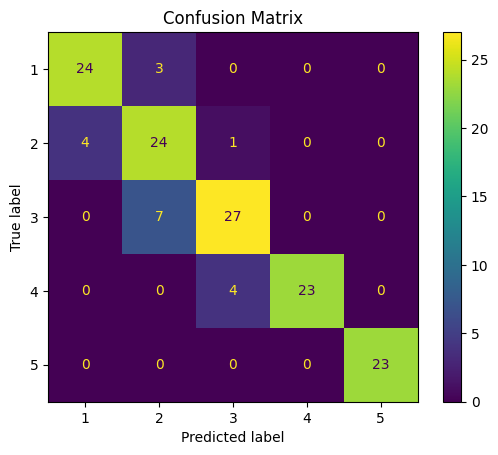

In [38]:

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# predict
y_pred = knn.predict(X_test)

# Evaluate the model
knn_report = classification_report(y_test, y_pred)
knn_cm = confusion_matrix(y_test, y_pred)


print("Classification Report:\n", knn_report)

fig, ax = plt.subplots()
knn_display = ConfusionMatrixDisplay(knn_cm, display_labels=knn.classes_)
ax.set(title='Confusion Matrix')
knn_display.plot(ax=ax);

Let's visualize a previously plotted plot again!

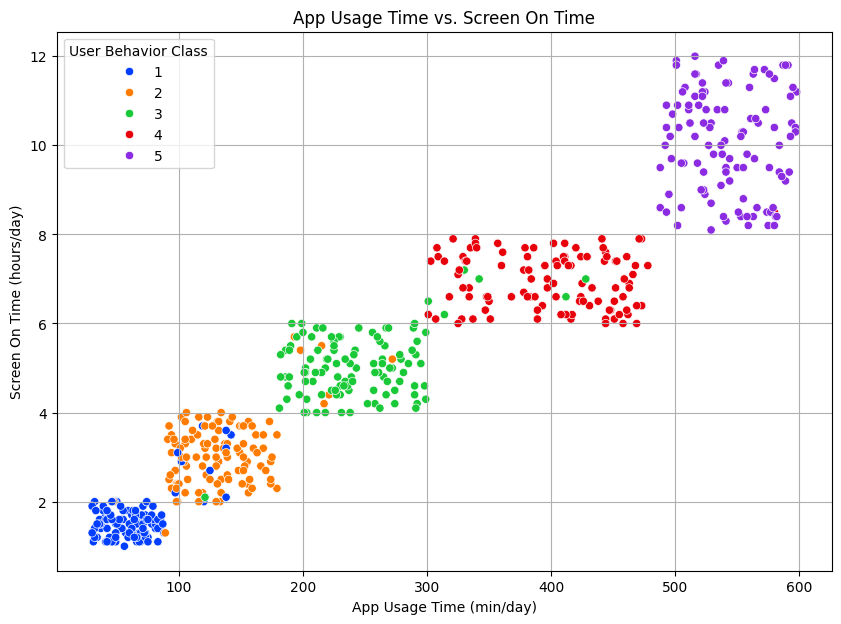

In [39]:
y_pred_train = knn.predict(X_train)
X_train_df = pd.DataFrame(X_train_org)  # Convert X_train to a DataFrame if it's not already
X_train_df['y_pred'] = y_pred_train  # Add y_pred as a new column

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=X_train_df,
    x='App Usage Time (min/day)',
    y='Screen On Time (hours/day)',
    hue='y_pred',
    palette='bright',
    alpha=1
)
plt.title('App Usage Time vs. Screen On Time')
plt.xlabel('App Usage Time (min/day)')
plt.ylabel('Screen On Time (hours/day)')
plt.legend(title='User Behavior Class')
plt.grid()
plt.show()


We are using only 2-dimension plot. We can observe that some training points are grouped in different class, which causes poor performance! This is due to the nature of KNN, where it doesn't pay attention to corrlations. it just map each sample in $d$-dimension space and just use distance metric to make preditions!


#### <font face="Verdana" color="green" size="+2">**Part 4: Model Evaluation Metrics** (5 points)
  
While accuracy is a helpful metric, it can be misleading in multi-class classification problems. You will calculate additional metrics such as **precision**, **recall**, **F1-score**, and the **confusion matrix** to gain a deeper understanding of the model's performance across different classes. These metrics will help you understand how well the model is distinguishing between the various user behavior classes.

Evaluate your models using precision, recall, F1-score, and the confusion matrix. Provide detailed insights into how well the model performs across each class and why each of works better or not.

In [40]:
# ALL requested metrics are calculated and showed in the previous section!

#### <font face="Verdana" color="green" size="+2"> **Part 5: Feature Importance Analysis** (4 points)

Understanding which features contribute most to the model’s decision-making process is crucial for interpretability. In this part, you will analyze the **feature importance** for models that support it (e.g., Decision Trees, Random Forests). This analysis will provide insights into which factors (e.g., `App Usage Time`, `Screen On Time`) play a significant role in determining the user behavior class.


Identify and explain the most important features driving the classification decisions. Highlight how these features relate to user behavior patterns.

**Key Steps**:
- For models like Decision Trees and Random Forests, extract and plot feature importance.
- Interpret which features are most influential in the classification task.


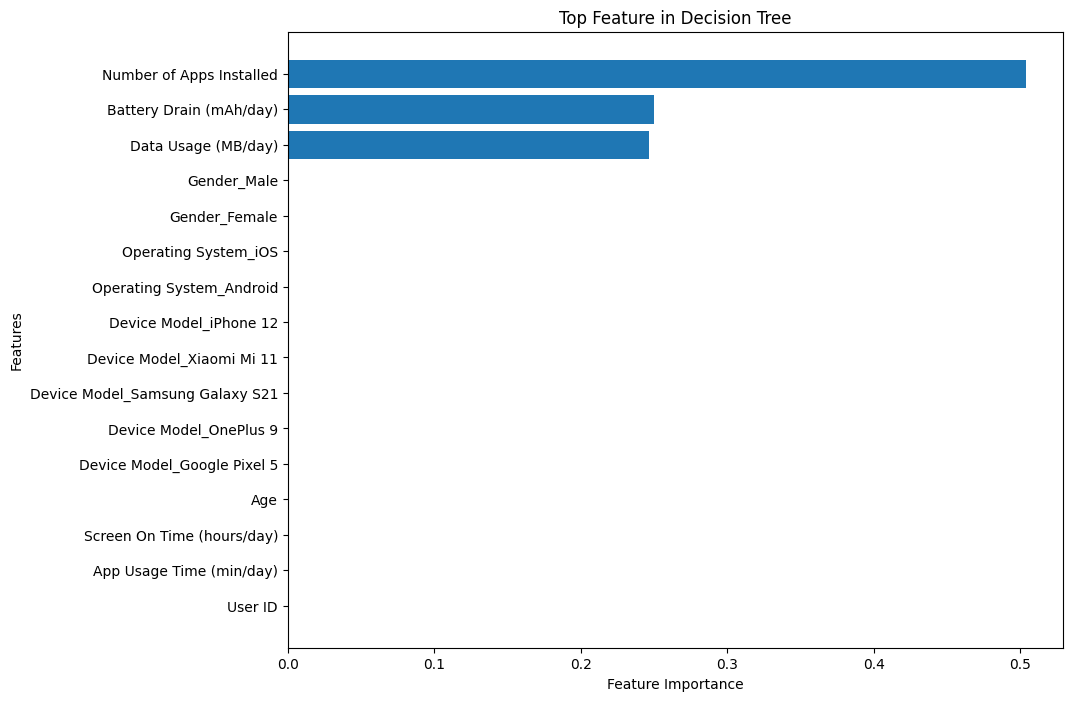

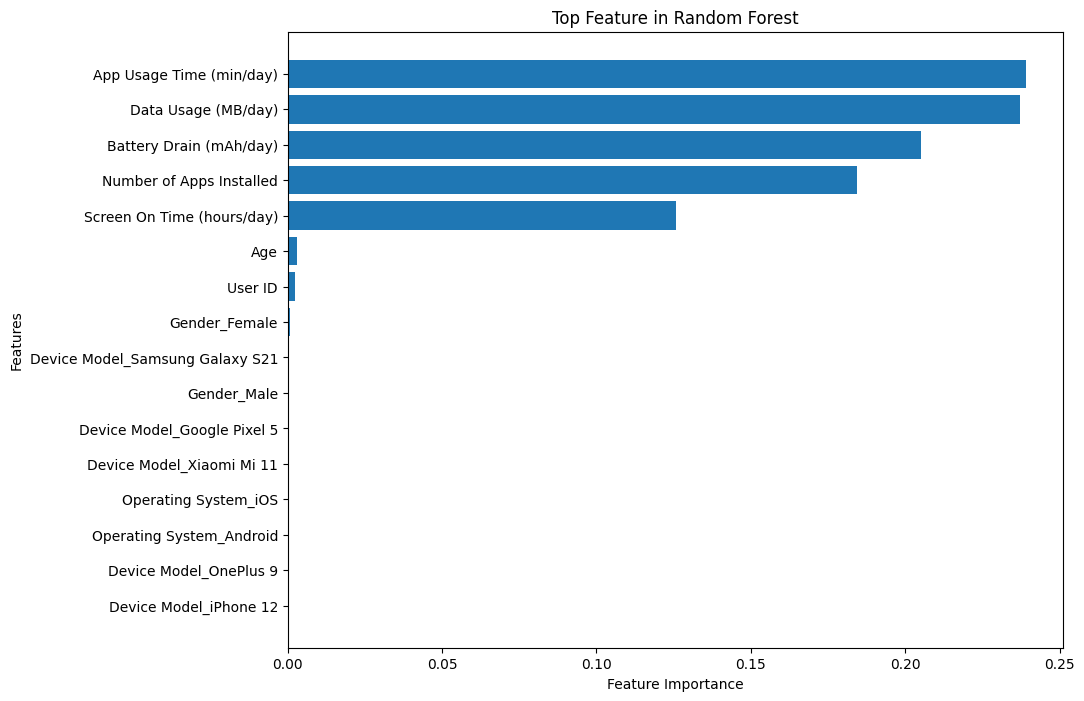

In [41]:
# I have copied this cell from my previous assignment
# prompt: which feature are important in best_rf_model? visualize a horizental plot for that.

import matplotlib.pyplot as plt

def feature_importance_metric(model , X_train , label):
  # Assuming 'model' is your trained RandomForestRegressor model
  feature_importances = model.feature_importances_
  feature_importances
  # # Create a DataFrame to store feature names and their importances
  feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

  # Sort the DataFrame by importance in descending order
  feature_importance_df = feature_importance_df.sort_values('Importance', ascending=True)

  # Create a horizontal bar plot
  plt.figure(figsize=(10, 8))
  plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
  plt.xlabel('Feature Importance')
  plt.ylabel('Features')
  plt.title('Top Feature in {}'.format(label))
  plt.show()

feature_importance_metric(tree , X_train , 'Decision Tree')
feature_importance_metric(rf , X_train , 'Random Forest')

Random forest uses more features, due to its natural characteristics.(It is a forest of decision trees, each tree probably uses a different set of features to make prediction). But Decision tree Overfit perfectly on the data using only 3 features.

### **<font face="Courier New" color="blue" size="+3">Quesiton 3: Strategies for Multi-Class Classification (5 points)</font>**

 In this question, you will explore and explain the two main strategies for handling multi-class classification problems with binary classifiers: **One-vs-Rest (OvR)** and **One-vs-One (OvO)**.

1. **One-vs-Rest (OvR)**:
   - Explain how the OvR strategy works.
   - Provide an example problem (e.g., classifying images of animals into one of three categories: cat, dog, and rabbit).
   - Discuss the advantages and disadvantages of using OvR for multi-class classification.

2. **One-vs-One (OvO)**:
   - Explain how the OvO strategy works.
   - Provide an example problem (e.g., classifying the same animal images, but in this case, using OvO).
   - Discuss the advantages and disadvantages of using OvO in comparison to OvR.

3. **Compare OvR and OvO**:
   - When might you choose to use OvR versus OvO?
   - What is the computational complexity of each approach?
   - Which method tends to perform better in practice, and why?



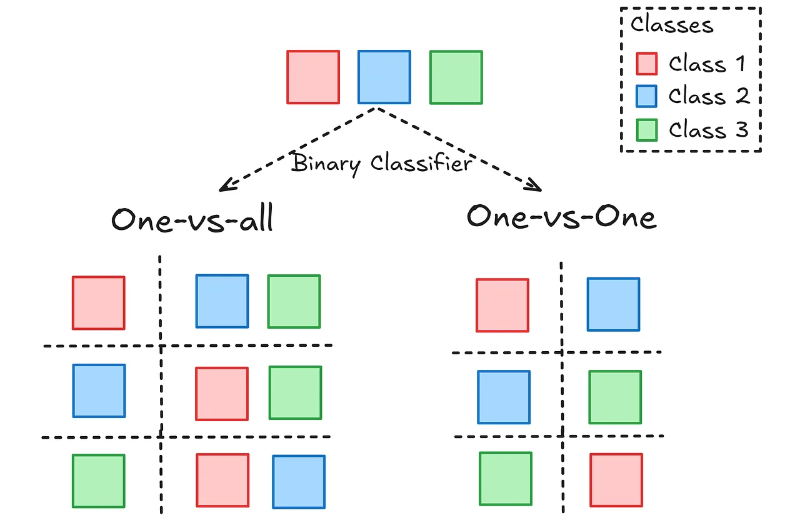


## 1. OvR :
if we have $k$ classes, we create $k$ binary classifiers, $C_1 , C_2 , ... , C_k$ . Each classifier $C_i$ is trained to distinguish between a specific class $i$ and the rest of the classes.

When we need to classify a new data point, we run it through all the binary classifiers. The classifier that gives the highest confidence score for its corresponding class is chosen as the final prediction.
* For a problem with $3$ classes, we'll train $3$ binary classifiers. we would train:


  1.   Classifier $C_1$: Cat vs. Non-Cat (Dog + Rabbit)
  2.   Classifier $C_2$: Dog vs. Non-Dog (Cat + Rabbit)
  3.   Classifier $C_3$: Rabbit vs. Non-Rabit (Cat + Dog)

Advantages of OvR:

1.  It's straightforward to implement, as you're essentially training multiple binary classifiers, which are generally easier to understand and train.
2.  It's computationally less expensive than OvO.

Disadvantages of OvR:
1. In the training phase, each binary classifier faces an imbalanced dataset (one class vs. the rest), which can affect the classifier's performance, especially for smaller classes.
2. The confidence scores from different binary classifiers might not be directly comparable, making it harder to interpret the model's certainty about its prediction.


## 2. OvO

For every pair of classes $i,j$ we create a classifier $C_{ij}$ to classify each sample either as class $i$ or as class $j$. This way, we will face $ k(k-1) / 2$ binary classifiers.

When classifying a new data point, we run it through all the pairwise classifiers. Each classifier "votes" for one of the two classes it's trained on. The class with the most votes is chosen as the final prediction. (Majority voting)

For our example with three classes (cat, dog, rabbit), we train:

1. Classifier $C_{12}$: Cat vs. Dog
2. Classifier $C_{13}$: Cat vs. Rabbit
3. Classifier $C_{23}$: Dog vs. Rabbit

**Advantages of OvO (compared to OvR):**
1. It is less sensitive to imbalance data. Each binary classifier is trained on a balanced dataset (one class vs. another), making it less susceptible to issues caused by class imbalance.
2.  in some cases, OvO can lead to better performance, as each classifier focuses on distinguishing between only two classes, potentially leading to more accurate decision boundaries.

**Disadvantages of OvO (compared to OvR):**

1. It requires training significantly more classifiers, especially for problems with many classes, increasing training time and computational resources. OvO can become less practical for problems with a large number of classes due to the increased computational burden.

## 3. Comparison
1.  **When to Choose**:

* OvR is generally preferred when you have a large number of classes and the dataset is relatively balanced. Also, it might be preferable when interpretability is important, since you can see the weight assigned to each feature.
* On the other hand OvOis often a better choice when dealing with imbalanced datasets or when the number of classes is moderate.


2. **Computational Complexity**:
* Based on what we discussed, OvR need to train Linear number of models:  $O(k)$ when we have $k$ classes.
* OvO Trains k(k-1)/2 binary classifiers, which is $O(k^2)$.

3. **Performance in Practice**:

* OvR: While simpler and faster to train, it can struggle with imbalanced datasets, where some classes have significantly more samples than others, since it can be biased toward the classes with larger number of training instances.
* OvO: Often performs better on imbalanced datasets as it focuses on pairwise comparisons, and has better capability to avoid bias. However, it can be slower to train, especially with many classes.


<hr>

### **<font face="Courier New" color="blue" size="+3">Quesiton 4: Handling Imbalanced Datasets in Classification (5 points)</font>**

2621b617-12a6-43e6-b23c-8e013350ab52_2101.avif

 Many real-world classification problems have imbalanced datasets, where some classes are much more frequent than others. This can lead to biased classifiers that perform poorly on the minority class.








#### <font face="Verdana" color="green" size="+1">**Problem:**
 Explain why imbalanced data can lead to biased classifiers. Discuss how it affects the performance of the classifier, especially in terms of metrics like accuracy, precision, recall, and F1-score.

During training, the classifier is exposed to far more examples of the majority class. As a result, it learns to prioritize the patterns associated with the majority class.
In models that establishes dicision boundaries (like SVM), The classifier might establish decision boundaries that are skewed towards the majority class. This can lead to misclassifying minority class instances as belonging to the majority class, as they fall on the wrong side of these boundaries.

**Accuracy**:
In an imbalanced dataset, accuracy can be misleadingly high if the classifier simply predicts the majority class for most cases.
For example, in a dataset where 99% of the instances belong to class A, a classifier that predicts class A for all inputs will achieve 99% accuracy, even though it completely ignores the minority class (class B).
This high accuracy does not mean the model is performing well; it simply reflects the model’s tendency to classify all samples as the majority class.


 **Precision:**
Precision is the ratio of true positives to the sum of true positives and false positives. It measures how often the model’s positive predictions are actually correct.
In an imbalanced dataset(where the minority class is considred as positive), the precision can be very low if the model frequently misclassifies minority instances as majority class instances.

On the other hand (where the majority class is considered as positive), the precision might be high.
Therefore, precision alone doesn’t provide a full picture of the model’s performance in imbalanced scenarios.

**Recall:**
Recall is the ratio of true positives to the sum of true positives and false negatives.
In imbalanced datasets, classifiers often have high recall for the majority class (since they tend to predict the majority class frequently) but low recall for the minority class. So, recall alone is not a good measure.

**F1-Score:**
F1-score is the harmonic mean of precision and recall, balancing the two metrics. It’s very useful in imbalanced settings because it doesn’t let high precision or high recall alone overly inflate the performance metric.
Since F1-score considers both precision and recall, a low F1-score for the minority class is a strong indicator that the model is not effective in handling that class.

#### <font face="Verdana" color="green" size="+2"> **Approaches:**
Describe at least three strategies that can be used to handle imbalanced datasets. Examples of strategies include:

* Resampling techniques (oversampling, undersampling)
* Synthetic data generation (e.g., SMOTE)
* Adjusting class weights



### Resampling Techniques (Oversampling and Undersampling)
***Oversampling:*** In this technique, we increase the number of instances in the minority class to make it comparable in size to the majority class. A common approach is to randomly duplicate instances from the minority class until both classes are balanced. It's good to introduce some variability if possible.

This approach can help the model learn more about the minority class since it has more samples to train on. Howeve, oversampling may lead to overfitting, especially if it just duplicates existing minority class samples without introducing any variability.


***Undersampling:*** In this technique, we reduce the number of instances in the majority class, usually by randomly discarding some of its samples.

Undersampling can speed up training since there’s less data, and it prevents the model from being overfit to the majority class. However, Undersampling might discard important information from the majority class, leading to poorer model performance if too much data is removed.


### Synthetic Data Generation (SMOTE and Variants)

Synthetic Data Generation is the process of generating fake samples, that mimic the real-world samples. Synthetic Data Generation has many different approaches.

As mentioned above, One way to solve this problem is to oversample the examples in the minority class. This can be achieved by simply duplicating examples from the minority class in the training dataset prior to fitting a model. This can balance the class distribution but does not provide any additional information to the model.

SMOTE is a more clever approach. it works by creating "synthetic" examples for the minority class rather than simply duplicating existing samples.

SMOTE works by selecting examples that are close in the feature space, drawing a line between the examples in the feature space and drawing a new sample at a point along that line.

Specifically, a random example from the minority class is first chosen. Then k of the nearest neighbors for that example are found (typically k=5). A randomly selected neighbor is chosen and a synthetic example is created at a randomly selected point between the two examples in feature space.

A general downside of the approach is that synthetic examples are created without considering the majority class, possibly resulting in ambiguous examples if there is a strong overlap for the classes.
Another downside is that SMOTE may cause over-generalization if the generated samples are not similar enough to real data points. It can also introduce noise if applied indiscriminately.


### Adjusting Class Weights
Class weighting is a technique where we assign higher importance (weight) to the minority class and lower importance to the majority class in the model’s loss function.

By adjusting class weights, you can penalize the model more heavily for misclassifying minority class samples. This incentivizes the model to pay more attention to the minority class during training.

Pros: Class weighting is computationally efficient because it doesn’t alter the size of the dataset. It’s also easy to implement, as many machine learning algorithms (e.g., logistic regression, decision trees, and neural networks) have parameters that support class weighting.
Cons: Setting class weights correctly requires some trial and error, as weighting too heavily might lead to overemphasis on the minority class, causing poor performance on the majority class.

#### <font face="Verdana" color="green" size="+2"> **Scenario:**
 Assume you are working with a dataset where 95% of the samples belong to class A and 5% belong to class B. How would you approach training a classifier on this dataset, and which strategy would you choose to improve its performance?

I personally try to use a combination of different techniques. First I might choose undersampling and oversampling to make class sizes more or less like each other.

Then, SMOTE (or any other synethic data generation technique, based on the problem) could be applied to create more data for the minority class

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 5: Multi-label Classification (30 points)</font>**

In this part, you'll work with a multi-label classification dataset and explore advanced classification strategies, including **OneVsRest (OvR)** and **Classifier Chains**. The task involves using **Classifier Chains** with multiple random orders and building an ensemble of these models to enhance prediction accuracy.

#### **Dataset**:
We will use the **Yeast dataset** from the `sklearn.datasets` library. This dataset has 2,417 datapoints with 103 features and 14 possible labels. Each datapoint may have more than one label, which makes it a multi-label classification problem.



---



---



---



---



---



---





#### <font face="Verdana" color="green" size="+2">**5.1: Data Loading and Preparation** (5 points)
- Load and Explore the **Yeast** dataset.
- Perform data splitting with an 80-20 train-test split.
- Normalize the features if necessary (standard scaling).


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score

In [43]:
yeast = fetch_openml(name='yeast', version=4)
X, y = yeast.data, yeast.target
y = pd.DataFrame(np.where(y == 'TRUE', True, False), columns=y.columns)  # labels in y are TRUE and FALSE, while it should be True and False =|
X.head()

,Att1,Att2,Att3,Att4,Att5,Att6,Att7,Att8,Att9,Att10,...,Att94,Att95,Att96,Att97,Att98,Att99,Att100,Att101,Att102,Att103
0,0.004168,-0.170975,-0.156748,-0.142151,0.058781,0.026851,0.197719,0.041850,0.066938,-0.056617,...,0.006166,-0.012976,-0.014259,-0.015024,-0.010747,0.000411,-0.032056,-0.018312,0.030126,0.124722
1,-0.103956,0.011879,-0.098986,-0.054501,-0.007970,0.049113,-0.030580,-0.077933,-0.080529,-0.016267,...,0.007680,0.027719,-0.085811,0.111123,0.050541,0.027565,-0.063569,-0.041471,-0.079758,0.017161
2,0.509949,0.401709,0.293799,0.087714,0.011686,-0.006411,-0.006255,0.013646,-0.040666,-0.024447,...,0.096277,-0.044932,-0.089470,-0.009162,-0.012010,0.308378,-0.028053,0.026710,-0.066565,-0.122352
3,0.119092,0.004412,-0.002262,0.072254,0.044512,-0.051467,0.074686,-0.007670,0.079438,0.062184,...,-0.083809,0.200354,-0.075716,0.196605,0.152758,-0.028484,-0.074207,-0.089227,-0.049913,-0.043893
4,0.042037,0.007054,-0.069483,0.081015,-0.048207,0.089446,-0.004947,0.064456,-0.133387,0.068878,...,-0.060467,0.044351,-0.057209,0.028047,0.029661,-0.050026,0.023248,-0.061539,-0.035160,0.067834


In [44]:
y.head()

,Class1,Class2,Class3,Class4,Class5,Class6,Class7,Class8,Class9,Class10,Class11,Class12,Class13,Class14
0,False,False,False,False,False,False,True,True,False,False,False,True,True,False
1,False,False,True,True,False,False,False,False,False,False,False,False,False,False
2,False,True,True,False,False,False,False,False,False,False,False,True,True,False
3,False,False,True,True,False,False,False,False,False,False,False,False,False,False
4,False,False,True,True,True,True,False,False,False,False,False,False,False,False


In [45]:
X.describe()

,Att1,Att2,Att3,Att4,Att5,Att6,Att7,Att8,Att9,Att10,...,Att94,Att95,Att96,Att97,Att98,Att99,Att100,Att101,Att102,Att103
count,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,...,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000
mean,0.001173,-0.000436,-0.000257,0.000265,0.001228,0.000475,0.001107,0.000420,0.001076,-0.000009,...,-0.000773,0.000464,-0.000515,0.000667,0.000324,-0.001483,-0.001047,-0.001539,0.000284,0.007605
std,0.097411,0.097885,0.097746,0.096969,0.096909,0.097306,0.097170,0.096803,0.096326,0.096805,...,0.093316,0.096684,0.096209,0.096635,0.096280,0.094369,0.096900,0.094211,0.093154,0.099368
min,-0.371146,-0.472632,-0.339195,-0.467945,-0.367044,-0.509447,-0.319928,-0.594498,-0.369712,-0.767128,...,-0.455191,-0.283594,-0.279408,-0.226420,-0.225374,-0.501572,-0.236589,-0.267052,-0.194079,-0.237752
25%,-0.053655,-0.058734,-0.057526,-0.057149,-0.058461,-0.060212,-0.058445,-0.062849,-0.063472,-0.065010,...,-0.054133,-0.056415,-0.056414,-0.059382,-0.058025,-0.053591,-0.063318,-0.059542,-0.054078,-0.077191
50%,0.003649,-0.003513,0.002892,-0.000153,0.005565,0.000321,0.006179,0.001436,0.003515,0.002432,...,-0.012893,-0.023595,-0.024313,-0.023059,-0.021942,-0.018216,-0.033623,-0.023519,-0.012007,0.022126
75%,0.057299,0.048047,0.061007,0.054522,0.066286,0.059908,0.068892,0.061418,0.064958,0.063096,...,0.027977,0.034937,0.036057,0.041430,0.035730,0.019583,0.038901,0.025408,0.028087,0.103185
max,0.520272,0.614114,0.353241,0.568960,0.307649,0.336971,0.351401,0.454591,0.419852,0.420876,...,0.609175,0.542867,0.547134,0.385928,0.540493,0.569250,0.509963,0.587358,0.700340,0.163431


### Train-Test Split

In [46]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# Normalize the features using StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train) , columns = X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test) , columns = X_test.columns)

#### <font face="Verdana" color="green" size="+2"> **5.2: OneVsRest (OvR) Classifier** (5 points)
- Train a **Logistic Regression** classifier on the dataset using the **OneVsRestClassifier** strategy.
- Calculate the **Jaccard Similarity Score** for the predicted labels.

#### Explanation Task:
- Explain how **OneVsRest** works in the context of multi-label classification and the limitations of treating each label independently.

- What is the Jaccard similarity, and why is it useful for multi-label classification?

- Report the Jaccard similarity score for the **OneVsRestClassifier** and interpret what it means in this multi-label context.



In [48]:
lr = LogisticRegression()
ovr = OneVsRestClassifier(lr)
ovr.fit(X_train, Y_train)
pred_ovr = ovr.predict(X_test)
ovr_jaccard_score = jaccard_score(Y_test, pred_ovr , average="samples")
print('score: {}'.format(ovr_jaccard_score))
print('this means that we are predicting almost half of the labels correctly.')

score: 0.5049496589269317
this means that we are predicting almost half of the labels correctly.


### OneVsRest
the OneVsRest (OVR) approach treats each label independently, For each label, a separate classifier is trained to predict whether that label is present or absent, ignoring other labels. So if there are 14 labels, OVR will train 14 classifiers, each one handling a different label and essentially posing the problem as "Is this label relevant for this instance or not?". After each classifier outputs a result, the combination of all classifier outputs is the final multi-label prediction. (each classifier output 0 or 1, and concatation of all of them creates a binary multi-label output)

***Limitations***

1. OvR ignores the dependencies between labels. Real-world data often has correlations between labels. OVR does not model these relationships, so it may miss patterns where certain labels frequently occur together
2.  As the number of labels grows, the number of classifiers increases, which increases the training time. This can make OVR impractical for very large multi-label sets.

### Jaccard similarity
The Jaccard similarity (or Jaccard index) is a measure of similarity between two sets. For two sets
$A$ and $B$ , it is defined as the size of the intersection divided by the size of the union:

Jaccard Similarity = $\frac{A ∩ B}{A \cup B}$

The Jaccard similarity ranges from 0 to 1, where 1 means the sets are identical and 0 means they have no elements in common. This measure is particularly useful for comparing categorical data or sets of labels.

In case of multi-label prediction, our prediction can be fully matched to the real labels, or fully unmatched, or partially matched. It's not a good idea to treat partially-match and fully-unmatched cases the same, so we can use Jaccard similarity to measure how similar our predictions are to real labels.

#### <font face="Verdana" color="green" size="+2">**Part 5.3: MultiOutputClassifier** (5 points)
- Train a **LogisticRegression** model using **MultiOutputClassifier** to predict all labels simultaneously.
- Evaluate the model’s performance using the **Jaccard similarity** and explain the meaning of this score.
- Calculate accuracy, precision, recall, and F1 score for each label.

#### Explanation Task:
- Explain how the **MultiOutputClassifier** works and why it treats each label independently.
- How do the metrics help in understanding model performance for multi-label tasks?

In [49]:
lr2 = LogisticRegression()
multi_lr = MultiOutputClassifier(lr2)
multi_lr.fit(X_train, Y_train)
pred_multi = multi_lr.predict(X_test)

multi_jaccard_score = jaccard_score(Y_test, pred_multi, average="samples")
print('score: {}'.format(multi_jaccard_score))
print('this means that we are predicting almost half of the labels correctly.')


score: 0.5049496589269317
this means that we are predicting almost half of the labels correctly.


According to sklearn's documentation : This strategy consists of fitting one classifier per target. This is a simple strategy for extending classifiers that do not natively support multi-target classification.

MultiOutputClassifier assumes label independence, meaning each label’s presence or absence is predicted without considering the others.

It seems that OvR and MultiOutput are doing the samething in case of multi-label classification! So all I had written for OvR will be applied here!

#### <font face="Verdana" color="green" size="+2">**5.4: Classifier Chain Model** (10 points)
- Implement a **Classifier Chain** model using Logistic Regression as the base classifier.
- Train 10 random chains with different label orderings and calculate the Jaccard similarity score for each.


Use sklearn’s **ClassifierChain** and Logistic Regression as the base classifier. Fit multiple chains (e.g., 10 chains) with random label orderings.

#### Explanation Task:
Explain why **Classifier Chains** may yield better performance compared to **OneVsRest** by modeling the relationships between labels.

#### Reporting Task:
For each of the 10 chains, report the **Jaccard Similarity Score** and discuss why the scores vary depending on the order of labels.

In [50]:
chains = []
lr = LogisticRegression()
for i in range(10):
  chains.append(ClassifierChain(lr, order="random" , random_state=i))

for chain in chains:
    chain.fit(X_train, Y_train)

Y_pred_chains =[]
chain_jaccard_scores = []
reportss = []
for chain in chains:
  pred = chain.predict_proba(X_test)
  Y_pred_chains.append(pred)
  chain_jaccard_scores.append(jaccard_score(Y_test, pred>=0.5, average="samples"))
  reportss.append(classification_report(Y_test, pred>=0.5))

In [51]:
#Create ensemble
Y_pred_ensemble = np.array(Y_pred_chains).mean(axis=0)
ensemble_jaccard_score = jaccard_score(Y_test, Y_pred_ensemble >= 0.5, average="samples")

In [52]:
model_scores = [ovr_jaccard_score]
model_names = ['OvR']
for i , c in enumerate(chain_jaccard_scores):
  model_scores.append(c)
  model_names.append(f'Chain {i+1}')

model_scores.append(ensemble_jaccard_score)
model_names.append('Ensemble')

df = pd.DataFrame({'Model': model_names, 'Jaccard Similarity': model_scores})
df

,Model,Jaccard Similarity
0,OvR,0.504950
1,Chain 1,0.500541
2,Chain 2,0.487592
3,Chain 3,0.512892
4,Chain 4,0.515572
5,Chain 5,0.501445
6,Chain 6,0.512128
7,Chain 7,0.508159
8,Chain 8,0.524590
9,Chain 9,0.526107


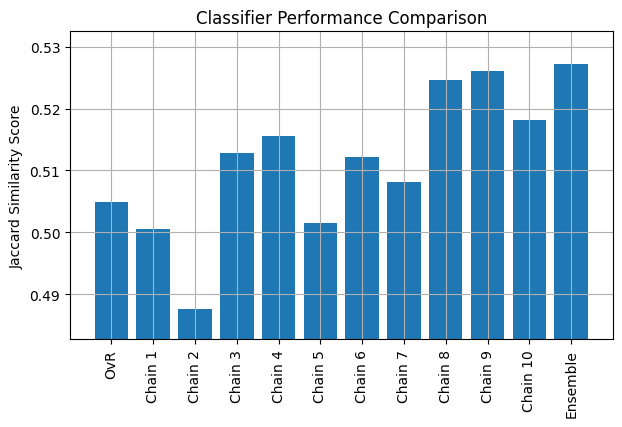

In [53]:
x_pos = np.arange(len(model_names))

fig, ax = plt.subplots(figsize=(7, 4))
ax.grid(True)
ax.set_title("Classifier Performance Comparison")
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation="vertical")
ax.set_ylabel("Jaccard Similarity Score")
ax.set_ylim([min(model_scores) * 0.99, max(model_scores) * 1.01])
ax.bar(x_pos, model_scores)
# plt.tight_layout()
plt.show()

Classifier Chains creates a chain of binary classifiers, where each classifier predicts the probability of a specific class given the features and the predictions of previous classifiers in the chain.
it exploits the relationships between classes by incorporating the predictions of previous classifiers as additional features.

The ensemble of binary classifiers are used as a chain where the prediction of a classifier in the chain is used as a feature for training the next classifier on a new label. Therefore, these additional features allow each chain to exploit correlations among labels.

But notice that because the models in each chain are arranged randomly there is significant variation in performance among the chains.


#### <font face="Verdana" color="green" size="+2">**Part 5.5: Results Comparison and Analysis** (5 points)
- Compare the Jaccard similarity, accuracy, precision, recall, and F1 score for models across all labels.
- Analyze and interpret why one method might perform better than the other.
- What are the advantages and disadvantages of each approach for multi-label classification?

**Explanation Required:**
- Discuss why **ClassifierChain** might perform better than **MultiOutputClassifier** or vice versa.
- What are the advantages and disadvantages of each approach for multi-label classification?



In [54]:
def calculate_metrics(y_true, y_pred):
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred, average='weighted')
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  return accuracy, precision, recall, f1

ovr_accuracy, ovr_precision, ovr_recall, ovr_f1 = calculate_metrics(Y_test, pred_ovr)
ensemble_accuracy, ensemble_precision, ensemble_recall, ensemble_f1 = calculate_metrics(Y_test, Y_pred_ensemble >= 0.5)


results = pd.DataFrame({
    'Model': ['OneVsRest', 'Ensemble'],
    'Jaccard Similarity': [ovr_jaccard_score,ensemble_jaccard_score],
    'Accuracy': [ovr_accuracy, ensemble_accuracy],
    'Precision': [ovr_precision, ensemble_precision],
    'Recall': [ovr_recall, ensemble_recall],
    'F1 Score': [ovr_f1, ensemble_f1]
})

In [55]:
chain_accuracy_list = []
chain_precision_list = []
chain_recall_list = []
chain_f1_list = []

for chain_pred in Y_pred_chains:
  accuracy, precision, recall, f1 = calculate_metrics(Y_test, chain_pred>=0.5)
  chain_accuracy_list.append(accuracy)
  chain_precision_list.append(precision)
  chain_recall_list.append(recall)
  chain_f1_list.append(f1)

results_chains = pd.DataFrame({
    'Model': ['Chain ' + str(i+1) for i in range(len(chains))],
    'Jaccard Similarity': chain_jaccard_scores,
    'Accuracy': chain_accuracy_list,
    'Precision': chain_precision_list,
    'Recall': chain_recall_list,
    'F1 Score': chain_f1_list
})
results_new = pd.concat([results, results_chains], ignore_index=True)
results_new.sort_values(by='Jaccard Similarity', ascending=False)

,Model,Jaccard Similarity,Accuracy,Precision,Recall,F1 Score
1,Ensemble,0.527179,0.200413,0.616494,0.618932,0.600669
10,Chain 9,0.526107,0.210744,0.616768,0.619417,0.599264
9,Chain 8,0.524590,0.200413,0.627264,0.625728,0.610383
11,Chain 10,0.518163,0.206612,0.609286,0.613107,0.598715
5,Chain 4,0.515572,0.194215,0.597584,0.613107,0.591360
4,Chain 3,0.512892,0.198347,0.611012,0.614563,0.600742
7,Chain 6,0.512128,0.200413,0.608607,0.603883,0.588453
8,Chain 7,0.508159,0.183884,0.594534,0.609223,0.589554
0,OneVsRest,0.504950,0.154959,0.635269,0.585922,0.588029
6,Chain 5,0.501445,0.194215,0.605129,0.605825,0.595932


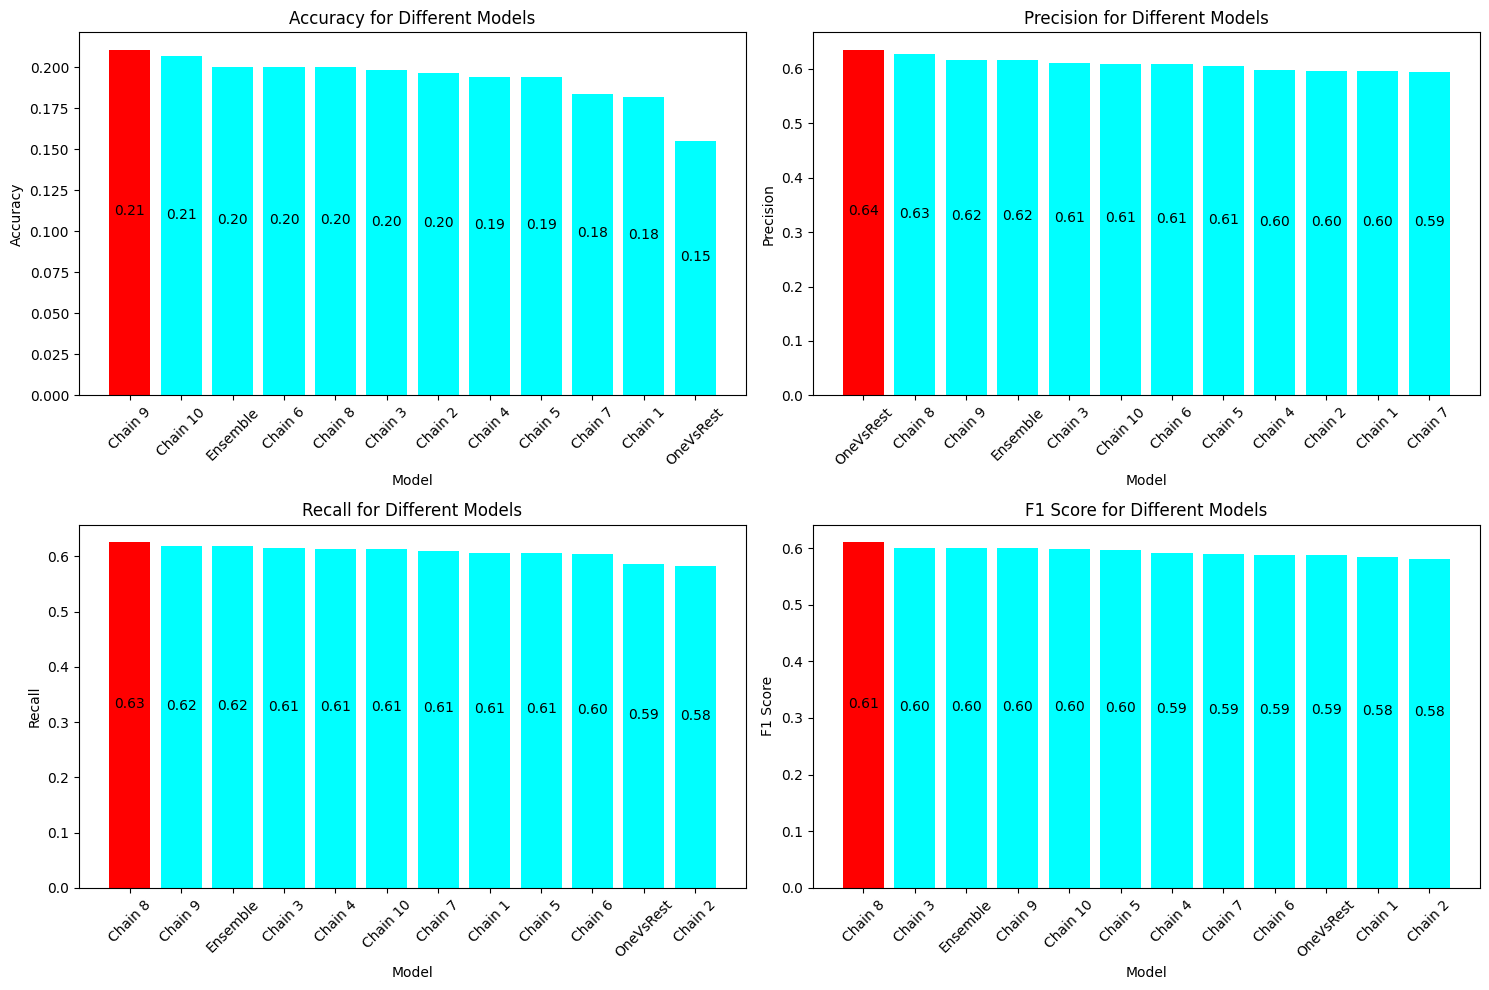

In [56]:
# AI DISCLAIMER
# prompt: plot 4 barchart subplots for results_new for 'Accuracy' , 'Precision' , 'Recall' , F1 Score' highligh best

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for i, metric in enumerate(metrics):
  row = i // 2
  col = i % 2
  ax = axes[row, col]

  # Sort the dataframe for highlighting the best performance
  sorted_results = results_new.sort_values(by=metric, ascending=False).reset_index()
  ax.bar(sorted_results['Model'], sorted_results[metric])
  ax.set_title(f'{metric} for Different Models')
  ax.set_xlabel('Model')
  ax.set_ylabel(metric)
  ax.tick_params(axis='x', rotation=45)
  # Highlighting the best score
  best_model_index = [0]

  colors = ['cyan' if val != max(sorted_results[metric]) else 'red' for val in sorted_results[metric]]
  bars = ax.bar(sorted_results['Model'], sorted_results[metric], color=colors)

  # bars = ax.bar(sorted_results['Model'][best_model_index], sorted_results[metric][best_model_index], color='red')
  for bar in bars:
      height = bar.get_height()
      ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height/2),
                  xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')


plt.tight_layout()
plt.show()

Analysis and Interpretation
- Classifier Chains often outperform OneVsRest because they model label dependencies, which can be crucial in multi-label settings.
- The choice between MultiOutputClassifier and ClassifierChain depends on the nature of the label relationships. If labels are largely independent, MultiOutputClassifier might be sufficient. If there are strong dependencies, ClassifierChain will likely be more effective.


#### <font face="Verdana" color="green" size="+2">AI Disclaimer

Promt: "give me a paragraph that states I have used gemini as AI assistant for this assingment. Make sure to include a sentence that this confess is also generated by gemini. Finally, ask Lord for forgiveness."

Result:

"In the spirit of transparency and academic integrity, I wish to disclose that I have utilized Google's Gemini AI assistant for various aspects of this assignment, including code generation, data analysis, and answering questions. I have diligently reviewed and critically evaluated all content generated by Gemini, ensuring its accuracy and incorporating my own understanding and insights to ensure the integrity and originality of the work. ***It is important to acknowledge that this very statement regarding the use of Gemini was also generated with the assistance of Gemini***. I humbly beseech the Lord for forgiveness for any shortcomings or unintended errors that may have arisen from this reliance on AI. May the lord forgive all of us."

